In [83]:
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

import os
import sys

sys.path.append(os.path.abspath(".."))

def vec(df):
    # 1. 前処理: frameでソートしておく（groupby内での処理を減らすため）
    df = df.sort_values(['particle', 'frame'])

    # 2. 差分計算（各グループの最初の一行はNaNになる）
    # diff() は pandas のメソッドを使うとインデックスが維持されるので安全です
    dx = df.groupby('particle')['x'].diff()
    dy = df.groupby('particle')['y'].diff()

    # 3. 速度ベクトルと単位ベクトルの計算
    v = np.sqrt(dx**2 + dy**2)

    df['theta'] = dx/v + 1j * dy/v

    return df


folder = '/Volumes/My Passport/Sasaki/MTsingleBeads'

MT_path = 'MTtrack.csv'
beads_path = 'beads_tracks.csv'
exp = "20260121/beads_trans_crop_crop"

pathM = os.path.join(folder, exp, MT_path)
pathB = os.path.join(folder, exp, beads_path)

dfM = pd.read_csv(pathM)
dfM = vec(dfM)

dfB = pd.read_csv(pathB)
dfB = vec(dfB)

def calculate_polar_order(df):
    """
    各フレームごとのポーラー度（Order Parameter）を算出する
    """
    # 1. 各フレームごとに複素ベクトルの平均を取る
    # thetaには既に単位ベクトル（dx/v + i*dy/v）が入っている前提
    group_avg = df.groupby('frame')['theta'].mean()
    
    # 2. 平均ベクトルの絶対値（長さ）を計算する
    # これが 1 に近いほど揃っており、0 に近いほどバラバラ
    polar_order = group_avg.abs()

    # 各フレームごとの粒子の数をカウント
    # 'theta' が NaN でないもの（速度が計算できているもの）だけを数えるのが実用的です
    counts = df.dropna(subset=['theta']).groupby('frame')['particle'].count()
    
    return polar_order, counts


In [84]:
x = dfB['x']
y = dfB['y']
frame = dfB['frame']

In [85]:
Lum = 20
scale = 0.11
L = Lum/scale



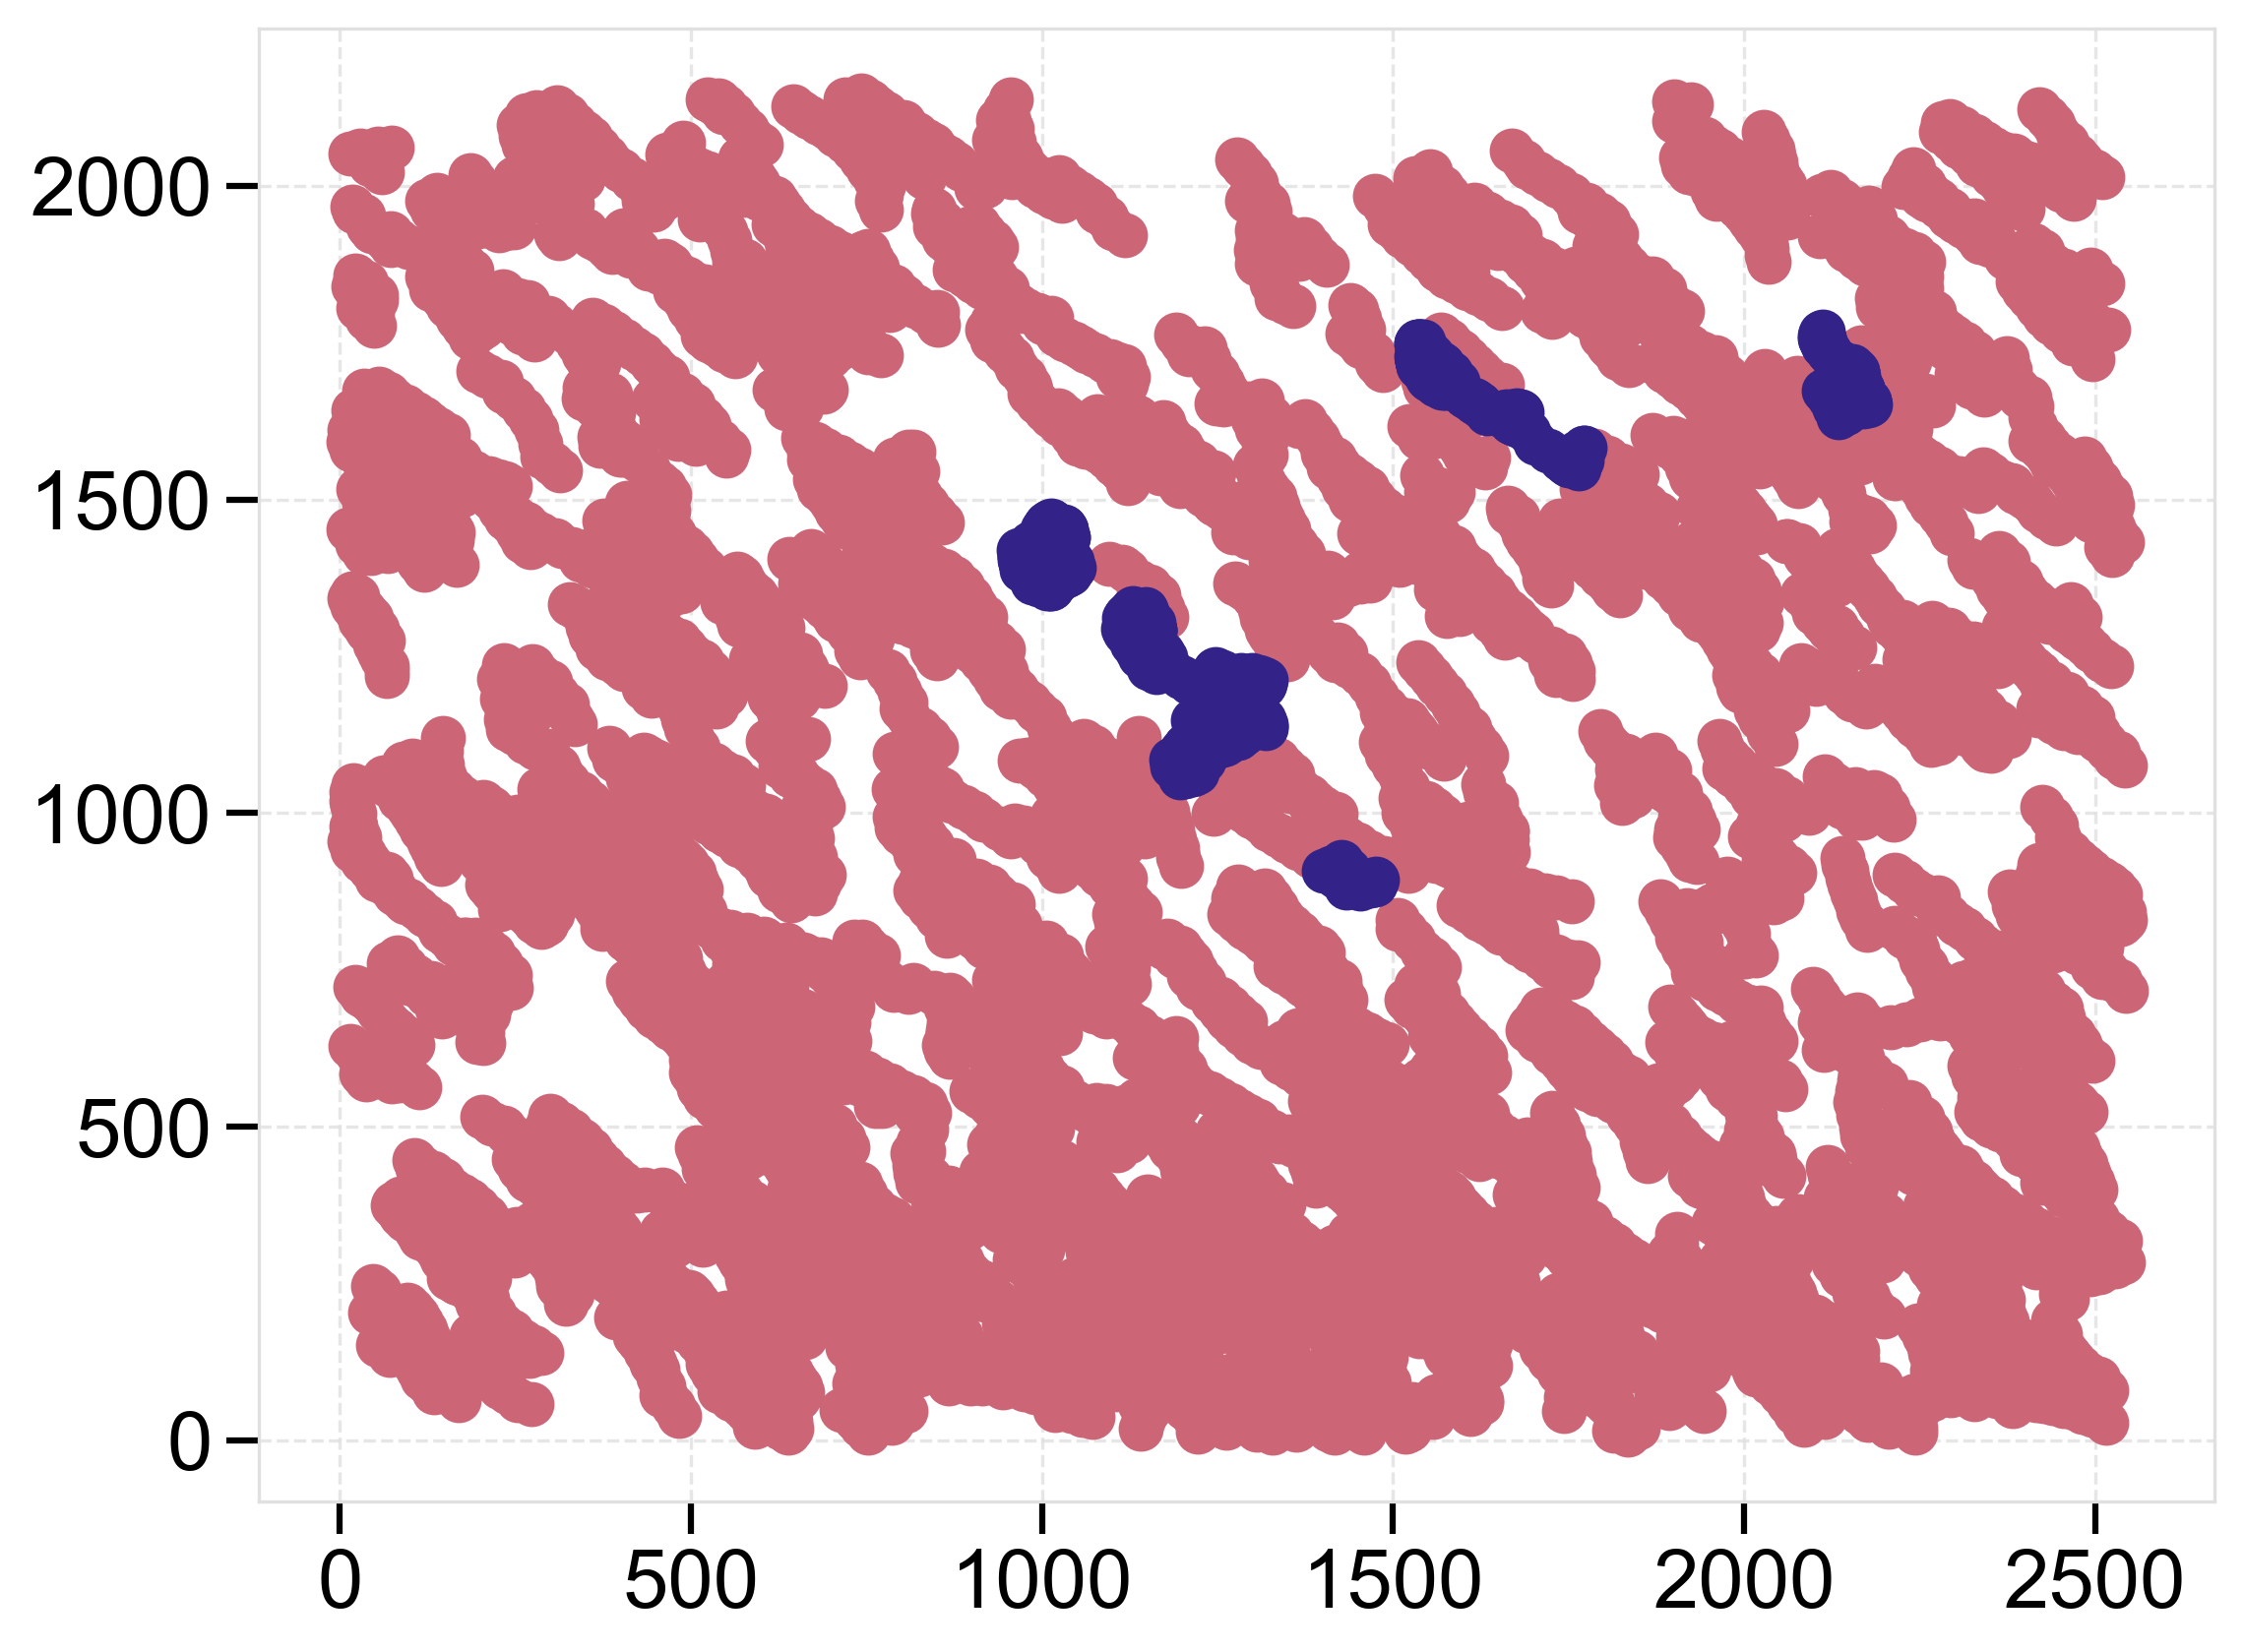

In [86]:
plt.scatter(dfM['x'], dfM['y'])
plt.scatter(dfB['x'], dfB['y'])

In [87]:
from scipy.spatial import KDTree
import numpy as np

results = []

for frame, data_b in dfB.groupby('frame'):
    # そのフレームのA粒子（current）
    data_a = dfM[dfM['frame'] == frame]
    if data_a.empty:
        continue
    
    # KDTreeを構築（currentの座標を使用）
    tree = KDTree(data_a[['x', 'y']].values)
    
    # 基準となるB粒子の座標をすべて取得
    centers_b = data_b[['x', 'y']].values
    
    # 半径 L/2 内のインデックスを一括取得 (円形領域の場合)
    # 正方形領域にこだわる場合は p=np.inf を指定します（チェビシェフ距離）
    indices = tree.query_ball_point(centers_b, r=L/2, p=np.inf)
    
    # A粒子の配向配列
    theta_a = data_a['theta'].values
    
    for idx_list, (p_id_b, row_b) in zip(indices, data_b.iterrows()):
        if len(idx_list) > 0:
            local_theta = theta_a[idx_list]
            # ここで local_theta を使って平均ポーラー度などを計算
            avg_polar = np.abs(np.nanmean(local_theta))
            
            results.append({
                'frame': frame,
                'particle_b': row_b['particle'],
                'local_polar': avg_polar,
                'neighbor_count': len(idx_list)
            })

res_df = pd.DataFrame(results)

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_64202/1472176792.py:29: RuntimeWarning: Mean of empty slice
  avg_polar = np.abs(np.nanmean(local_theta))


In [88]:
res_df[res_df['neighbor_count']>1]

,frame,particle_b,local_polar,neighbor_count
0,4,5.0+0.0j,0.995167,2
1,5,5.0+0.0j,0.999981,2
3,7,5.0+0.0j,0.994035,2
4,8,5.0+0.0j,0.998228,2
5,9,5.0+0.0j,0.995060,2
7,10,5.0+0.0j,0.871554,2
10,11,6.0+0.0j,1.000000,2
15,14,6.0+0.0j,1.000000,2
17,15,6.0+0.0j,0.572576,3
18,16,6.0+0.0j,0.999371,2
